### SPI (Standardized Precipitation Index)
#### Indice standardisé de la précipitation qui permet de caractériser les anomalies de précipitations et détécter les années humides et séches à différentes échelles de temps. Indice de la sécheresse climatique-météorologique, centré sur la moyenne à long terme et réduit par l’écart-type à long terme.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
dff = pd.read_csv( "PTVent19502023.csv", encoding='utf-8', sep=";")
fd = pd.read_csv("Q_60_latest-2024-2025_RR-T-Vent.csv", sep=";")
df = pd.concat([dff, fd])

In [3]:
df = df[["NUM_POSTE", "NOM_USUEL", "LAT", "LON", "AAAAMMJJ", "RR", "TNTXM"]]
df["date"] = pd.to_datetime(df["AAAAMMJJ"], format = "%Y%m%d")
df.drop("AAAAMMJJ", axis=1, inplace=True)
df["Annee"] = df["date"].dt.year

In [4]:
df

,NUM_POSTE,NOM_USUEL,LAT,LON,RR,TNTXM,date,Annee
0,60005001,ACY-EN-MULTIEN ECOLE,49.101667,2.955000,0.0,NaN,1950-01-01,1950
1,60005001,ACY-EN-MULTIEN ECOLE,49.101667,2.955000,5.7,NaN,1950-01-02,1950
2,60005001,ACY-EN-MULTIEN ECOLE,49.101667,2.955000,4.9,NaN,1950-01-03,1950
3,60005001,ACY-EN-MULTIEN ECOLE,49.101667,2.955000,1.5,NaN,1950-01-04,1950
4,60005001,ACY-EN-MULTIEN ECOLE,49.101667,2.955000,1.1,NaN,1950-01-05,1950
...,...,...,...,...,...,...,...,...
9955,60652001,VALDAMPIERRE,49.303167,2.048333,1.4,13.0,2025-10-21,2025
9956,60652001,VALDAMPIERRE,49.303167,2.048333,10.5,13.0,2025-10-22,2025
9957,60652001,VALDAMPIERRE,49.303167,2.048333,13.2,10.3,2025-10-23,2025
9958,60652001,VALDAMPIERRE,49.303167,2.048333,7.0,8.2,2025-10-24,2025


In [5]:
df['date'] = pd.to_datetime(df['date'])
df['day'] = df["date"].dt.day
df["n_obs"] = df.groupby(["NUM_POSTE", "Annee"])["RR"].transform("count")

df= df[df["n_obs"] >= 270]

In [6]:
df["n_obs"].min()

np.int64(273)

In [7]:
annual = df.groupby(['NOM_USUEL', 'Annee'])['RR'].sum().reset_index(name='P_annuel')
annual["Annee"].sort_values(ascending=True)

0       1950
2084    1950
97      1950
1930    1950
368     1950
        ... 
2023    2025
234     2025
2038    2025
2176    2025
128     2025
Name: Annee, Length: 2676, dtype: int32

In [8]:
stats = annual.groupby('NOM_USUEL')['P_annuel'].agg(['mean', 'std']).reset_index()
stats.rename(columns={'mean': 'mu_P', 'std': 'sigma_P'}, inplace=True)
stats

,NOM_USUEL,mu_P,sigma_P
0,ACY-EN-MULTIEN ECOLE,745.100000,0.848528
1,AIRION,658.854545,131.321157
2,ARSY,720.396296,130.774843
3,AUNEUIL,834.480435,142.803947
4,BABOEUF SAINT-HUBERT - ECLUSE,655.380000,134.433553
...,...,...,...
92,VALDAMPIERRE,796.430667,144.792282
93,VAUDANCOURT,718.445946,138.625618
94,VENETTE,623.830303,89.947243
95,VIEUX-MOULIN,710.766667,181.920719


In [9]:
annual = annual.merge(stats, on="NOM_USUEL")
annual 

,NOM_USUEL,Annee,P_annuel,mu_P,sigma_P
0,ACY-EN-MULTIEN ECOLE,1950,744.5,745.100000,0.848528
1,ACY-EN-MULTIEN ECOLE,1951,745.7,745.100000,0.848528
2,AIRION,1989,498.4,658.854545,131.321157
3,AIRION,1990,546.4,658.854545,131.321157
4,AIRION,1991,512.4,658.854545,131.321157
...,...,...,...,...,...
2671,WAVIGNIES,2008,506.5,534.583333,47.832433
2672,WAVIGNIES,2009,535.0,534.583333,47.832433
2673,WAVIGNIES,2010,455.5,534.583333,47.832433
2674,WAVIGNIES,2011,550.5,534.583333,47.832433


In [10]:
stations = ["AIRION", "BREUIL-LE-VERT", "ERQUERY", "FITZ-JAMES", "FROISSY",
             "MESNIL-SUR-BULLES", "PLAINVAL", "QUINQUEMPOIX", "WAVIGNIES"]

dataframe = annual[annual["NOM_USUEL"].isin(stations)]
dataframe

,NOM_USUEL,Annee,P_annuel,mu_P,sigma_P
2,AIRION,1989,498.4,658.854545,131.321157
3,AIRION,1990,546.4,658.854545,131.321157
4,AIRION,1991,512.4,658.854545,131.321157
5,AIRION,1992,682.6,658.854545,131.321157
6,AIRION,1993,734.6,658.854545,131.321157
...,...,...,...,...,...
2671,WAVIGNIES,2008,506.5,534.583333,47.832433
2672,WAVIGNIES,2009,535.0,534.583333,47.832433
2673,WAVIGNIES,2010,455.5,534.583333,47.832433
2674,WAVIGNIES,2011,550.5,534.583333,47.832433


In [11]:
pd.options.mode.chained_assignment = None

dataframe["SPI"] = (dataframe["P_annuel"] - dataframe["mu_P"])/dataframe["sigma_P"]

In [12]:
dataframe["NOM_USUEL"].unique()

array(['AIRION', 'BREUIL-LE-VERT', 'ERQUERY', 'FITZ-JAMES', 'FROISSY',
       'MESNIL-SUR-BULLES', 'PLAINVAL', 'QUINQUEMPOIX', 'WAVIGNIES'],
      dtype=object)

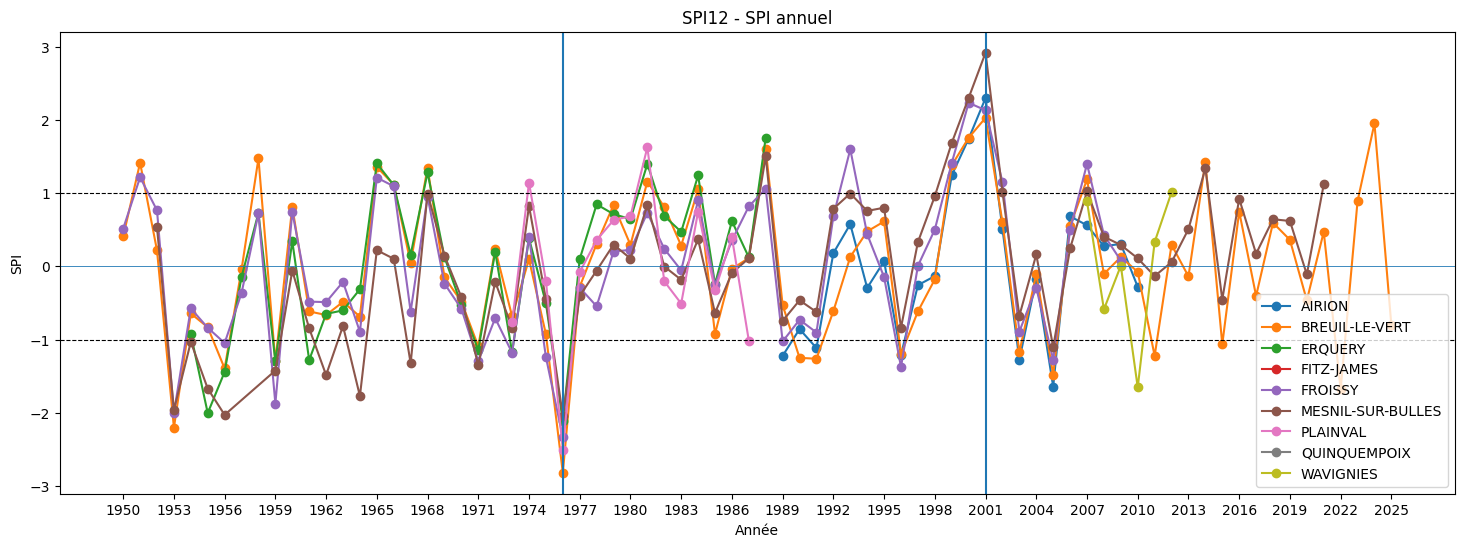

In [13]:
plt.figure(figsize=(18,6))

for i in dataframe["NOM_USUEL"].unique():
    data = dataframe[dataframe["NOM_USUEL"] == i]
    plt.plot(data["Annee"], data["SPI"], marker='o', label=i)
    
plt.xlabel("Année")
plt.xticks(ticks= np.arange(1950, 2026, 3))
plt.axhline(0, linewidth=0.6)
plt.axhline(1, linestyle="--", linewidth=0.8, c="black")
plt.axhline(-1, linestyle="--", c="black", linewidth="0.8")
plt.ylabel("SPI")
plt.title("SPI12 - SPI annuel")
plt.legend()
plt.axvline(1976)
plt.axvline(2001)
#plt.grid(True)
plt.show()
    

# Thiessen
### Analyse de pluie et la température par la méthode de Thiessen (zone d'influence de chaque station)

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
weights = {"FROISSY": 76,
           "FITZ-JAMES": 21,
           "MESNIL-SUR-BULLES": 94,
           "WAVIGNIES": 38,
           "BREUIL-LE-VERT": 60,
           "QUINQUEMPOIX": 7,
           "PLAINVAL": 36,
           "AIRION": 58,
           "ERQUERY": 70}


df["date"] = pd.to_datetime(df["date"])


wdf = pd.DataFrame(list(weights.items()), columns=["NOM_USUEL", "w"])
df_ = df.merge(wdf, on="NOM_USUEL", how="inner").copy()


def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return (series[mask] * weights[mask]).sum() / weights[mask].sum()


agg = (
    df_.groupby("date")
       .apply(lambda g: pd.Series({
           "n_RR": g["RR"].notna().sum(),
           "n_T": g["TNTXM"].notna().sum(),
           "Pre_Moy": weighted_mean(g["RR"], g["w"]),
           "T_moy": weighted_mean(g["TNTXM"], g["w"])
       }))
       .reset_index())


df_compare = df_.merge(agg, on="date", how="left")


daily_means = df_compare[["date", "NOM_USUEL", "RR", "TNTXM", "Pre_Moy", "T_moy", "n_RR", "n_T"]].sort_values(["date", "NOM_USUEL"])
daily_summary = agg.sort_values("date").copy()


In [16]:
daily_summary["year"] = daily_summary["date"].dt.year
pre_annuel_bassin = daily_summary.groupby("year")["Pre_Moy"].sum()
pre_moyen_annuel_bassin = pre_annuel_bassin.sum() / (len(pre_annuel_bassin))

#### Précipitation moyenne anuuelle du bassin

In [17]:
pre_moyen_annuel_bassin

np.float64(683.7179460462793)

In [18]:
daily_summary["Pre_Moy"].sort_values(ascending=True)

3650      0.000000
65        0.000000
64        0.000000
63        0.000000
62        0.000000
           ...    
15511    44.235417
13749    46.683929
21694    48.824540
27310    50.900000
23583    64.409091
Name: Pre_Moy, Length: 27692, dtype: float64

In [19]:
daily_summary.loc[daily_summary["Pre_Moy"]>45]

,date,n_RR,n_T,Pre_Moy,T_moy,year
13749,1987-08-24,5.0,1.0,46.683929,16.100000,1987
21694,2009-05-25,5.0,2.0,48.824540,20.585417,2009
23583,2014-07-27,2.0,0.0,64.409091,NaN,2014
27310,2024-10-09,1.0,1.0,50.900000,13.800000,2024


# Etude hydrologique (crue-étiage)

In [20]:
df_Q = pd.read_csv("H7602010_debit_Breche.csv", sep=",")

In [21]:
df_Q.rename(columns={"month (TU)": "month", "Valeur (en m³/s)": "Q_cumec"}, inplace=True)

In [22]:
df_Q["Date (TU)"] = pd.to_datetime(df_Q["Date (TU)"])
df_Q.rename(columns={"Date (TU)": "Date"}, inplace=True)

In [23]:
df_Q["Date"] = pd.to_datetime(df_Q["Date"]).dt.date

In [24]:
df_Q

,Date,Q_cumec,Statut,Qualification,Méthode,Continuité
0,2006-01-01,1.65,16,20,10,0
1,2006-01-02,1.58,16,20,10,0
2,2006-01-03,1.49,16,20,10,0
3,2006-01-04,1.58,16,20,10,0
4,2006-01-05,1.50,16,20,10,0
...,...,...,...,...,...,...
6915,2025-10-27,1.79,8,16,8,0
6916,2025-10-28,1.72,8,16,8,0
6917,2025-10-29,1.76,8,16,8,0
6918,2025-10-30,1.86,4,16,8,0


In [25]:
daily_summary["Date"] = pd.to_datetime(daily_summary["date"])
df_Q["Date"] = pd.to_datetime(df_Q["Date"])

DATAFRAME = pd.merge(daily_summary, df_Q, on="Date", validate="one_to_one")

DATAFRAME["month"] = pd.to_datetime(DATAFRAME["Date"]).dt.month

In [26]:
DATAFRAME

,date,n_RR,n_T,Pre_Moy,T_moy,year,Date,Q_cumec,Statut,Qualification,Méthode,Continuité,month
0,2006-01-01,4.0,1.0,3.167361,5.2,2006,2006-01-01,1.65,16,20,10,0,1
1,2006-01-02,4.0,1.0,0.159028,3.4,2006,2006-01-02,1.58,16,20,10,0,1
2,2006-01-03,4.0,1.0,3.034722,1.8,2006,2006-01-03,1.49,16,20,10,0,1
3,2006-01-04,4.0,1.0,0.314583,2.9,2006,2006-01-04,1.58,16,20,10,0,1
4,2006-01-05,4.0,1.0,0.490972,-0.4,2006,2006-01-05,1.50,16,20,10,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6909,2025-10-21,1.0,1.0,0.800000,14.5,2025,2025-10-21,1.66,8,16,8,0,10
6910,2025-10-22,1.0,1.0,5.000000,13.2,2025,2025-10-22,1.65,8,16,8,0,10
6911,2025-10-23,1.0,1.0,8.000000,11.5,2025,2025-10-23,1.84,8,16,8,0,10
6912,2025-10-24,1.0,1.0,3.400000,9.3,2025,2025-10-24,1.82,8,16,8,0,10


In [27]:
DATAFRAME.loc[DATAFRAME["Pre_Moy"]>45].tail(5)

,date,n_RR,n_T,Pre_Moy,T_moy,year,Date,Q_cumec,Statut,Qualification,Méthode,Continuité,month
1240,2009-05-25,5.0,2.0,48.824540,20.585417,2009,2009-05-25,2.51,16,20,10,0,5
3129,2014-07-27,2.0,0.0,64.409091,NaN,2014,2014-07-27,2.47,16,20,10,0,7
6532,2024-10-09,1.0,1.0,50.900000,13.800000,2024,2024-10-09,2.87,16,20,8,0,10


In [28]:
DATAFRAME.to_csv("DATAFRAME.csv", sep=",")

In [29]:
DATAFRAME["Annee"] = DATAFRAME["Date"].dt.year


Q_annuel = DATAFRAME.groupby("Annee")["Q_cumec"].mean()
P_annuel = DATAFRAME.groupby("Annee")["Pre_Moy"].sum()
T_annuel = DATAFRAME.groupby("Annee")["T_moy"].mean()

Donnee_annuel = {"annee" : np.arange(1,21,1),
                 "Q" : Q_annuel,
                 "P" : P_annuel,
                 "T" : T_annuel}


# QMNA

In [30]:
from scipy.stats import norm

In [31]:
moyenne_mensuel = DATAFRAME.groupby(["Annee", "month"])["Q_cumec"].mean().reset_index()
moyenne_mensuel_pivot = moyenne_mensuel.pivot(index="month", columns="Annee", values="Q_cumec")


QMNA = moyenne_mensuel_pivot.min()



log_QMNA = np.log(QMNA.values)
mean_log_QMNA = np.mean(log_QMNA)
std_log_QMNA = np.std(log_QMNA, ddof=1)


T = np.concatenate((np.arange(2, 101, 2), [5, 25, 75]))
QMNAT = {}

for t in T:
    z = norm.ppf(1/t, loc=mean_log_QMNA, scale=std_log_QMNA)
    QMNAT[t] = round(float(np.exp(z)), 2)

QMNAT = pd.DataFrame({
    "T": list(QMNAT.keys()),
    "QMNA": list(QMNAT.values())
})


QMNAT.head(5)

,T,QMNA
0,2,1.37
1,4,1.20
2,6,1.14
3,8,1.10
4,10,1.07


# VCN30

In [32]:
DATAFRAME["Date"] = pd.to_datetime(DATAFRAME["Date"])
DATAFRAME["Annee"] = DATAFRAME["Date"].dt.year


DATAFRAME["Q30"] = DATAFRAME["Q_cumec"].rolling(window=30, min_periods=30).mean()

VCN30 = DATAFRAME.groupby("Annee")["Q30"].min().round(2)

VCN30 = VCN30.reset_index()
VCN30.head()

,Annee,Q30
0,2006,1.23
1,2007,1.51
2,2008,1.57
3,2009,1.24
4,2010,1.39


# Analyse fréquentiel des crues

,Annee,Q_cumec,rang,Freq_non_depasse,T,u
0,2006,3.00,1,0.047619,1.0,-1.113344
1,2015,3.10,2,0.095238,1.1,-0.855000
2,2017,3.11,3,0.142857,1.2,-0.665730
3,2023,3.17,4,0.190476,1.2,-0.505750
4,2012,3.64,5,0.238095,1.3,-0.361224


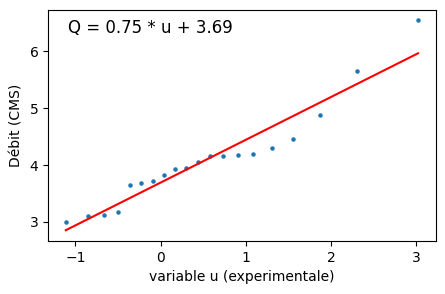

In [33]:
Max_deb = DATAFRAME.groupby("Annee")["Q_cumec"].max()
Max_deb_sorted = Max_deb.sort_values(ascending=True)
Max_deb_sorted = Max_deb_sorted.reset_index()
Max_deb_sorted["rang"] = np.arange(1, 21)
Max_deb_sorted["Freq_non_depasse"] = Max_deb_sorted["rang"] / (len(Max_deb_sorted["rang"]) + 1)
Max_deb_sorted["T"] = (1 / (1 - (Max_deb_sorted["Freq_non_depasse"]))).round(1)
Max_deb_sorted["u"] = (-np.log(-np.log(Max_deb_sorted["Freq_non_depasse"])))


a, b = np.polyfit(Max_deb_sorted["u"], Max_deb_sorted["Q_cumec"], 1)
u_vals = np.linspace(Max_deb_sorted["u"].min(), Max_deb_sorted["u"].max(), 100)
courbe_tendance = a * u_vals + b


plt.figure(figsize=(5, 3))
plt.plot(u_vals, courbe_tendance, color="red", label="régression linéaire")
plt.scatter(Max_deb_sorted["u"], Max_deb_sorted["Q_cumec"], marker=".", s=20)
#plt.xscale("log")

Equation = f"Q = {a:.2f} * u + {b:.2f}"
plt.text(0.05, 0.90, Equation, transform=plt.gca().transAxes,
          fontsize=12, color="black", 
          bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


plt.xlabel("variable u (experimentale)")
plt.ylabel("Débit (CMS)")



Max_deb_sorted.head()

In [34]:
T = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 1000], dtype=float)

F_np = 1 - (1 / T)                       
u = -np.log(-np.log(F_np))               
Q_extrap = a * u + b                  

df_extrap = pd.DataFrame({
    "T": T,
    "F_non_depassement": F_np,
    "u": u,
    "Q_extrap": Q_extrap
}).sort_values("T")

df_extrap.head()

,T,F_non_depassement,u,Q_extrap
0,20.0,0.950000,2.970195,5.929528
1,30.0,0.966667,3.384294,6.241888
2,40.0,0.975000,3.676247,6.462110
3,50.0,0.980000,3.901939,6.632352
4,60.0,0.983333,4.085953,6.771156


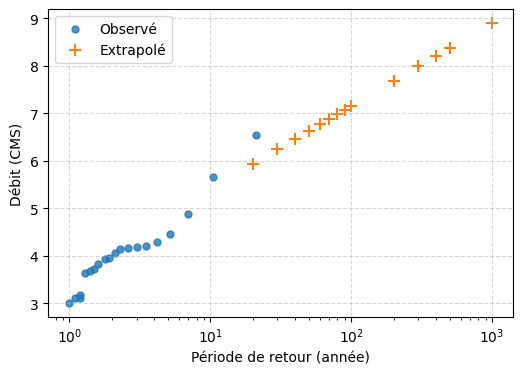

In [35]:
plt.figure(figsize=(6,4))

plt.scatter(Max_deb_sorted["T"], Max_deb_sorted["Q_cumec"], s=25, label="Observé", alpha=0.8)
plt.scatter(df_extrap["T"], df_extrap["Q_extrap"], marker="+", s=80, label="Extrapolé")
plt.xscale("log")
plt.xlabel("Période de retour (année)")
plt.ylabel("Débit (CMS)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


# All in one (palette adaptée au daltonisme)

In [36]:
DATAFRAME_mensuelle_sum_P = DATAFRAME.groupby(["Annee", "month"])["Pre_Moy"].sum()
DATAFRAME_sum_P = DATAFRAME_mensuelle_sum_P.reset_index()
DATAFRAME_mensuelle_sum_moy_P = DATAFRAME_sum_P.groupby("month")["Pre_Moy"].mean()
DATAFRAME_mensuelle_sum_moy_P = DATAFRAME_mensuelle_sum_moy_P.reset_index()

DATAFRAME_mensuelle_mean_Q = DATAFRAME.groupby(["Annee", "month"])["Q_cumec"].mean()
DATAFRAME_mean_Q = DATAFRAME_mensuelle_mean_Q.reset_index()
DATAFRAME_mensuelle_mean_mean_Q = DATAFRAME_mean_Q.groupby("month")["Q_cumec"].mean()
DATAFRAME_mensuelle_mean_mean_Q = DATAFRAME_mensuelle_mean_mean_Q.reset_index()

DATAFRAME_mensuelle_mean_T = DATAFRAME.groupby(["Annee", "month"])["T_moy"].mean()
DATAFRAME_mean_T = DATAFRAME_mensuelle_mean_T.reset_index()
DATAFRAME_mensuelle_mean_mean_T = DATAFRAME_mean_T.groupby("month")["T_moy"].mean()
DATAFRAME_mensuelle_mean_mean_T = DATAFRAME_mensuelle_mean_mean_T.reset_index()

In [37]:
TEMPERORY = pd.merge(DATAFRAME_mensuelle_sum_moy_P, DATAFRAME_mensuelle_mean_mean_Q, on="month")
DATAFRAME_MOY_MENSUELLE_INTERANNUELLE = pd.merge(TEMPERORY,  DATAFRAME_mensuelle_mean_mean_T, on="month")
DATAFRAME_MOY_MENSUELLE_INTERANNUELLE.head()

,month,Pre_Moy,Q_cumec,T_moy
0,1,65.960586,2.331969,3.937024
1,2,51.992341,2.530660,5.120137
2,3,52.800056,2.550772,7.564191
3,4,36.406869,2.319250,10.380718
4,5,67.996377,2.126935,13.840547


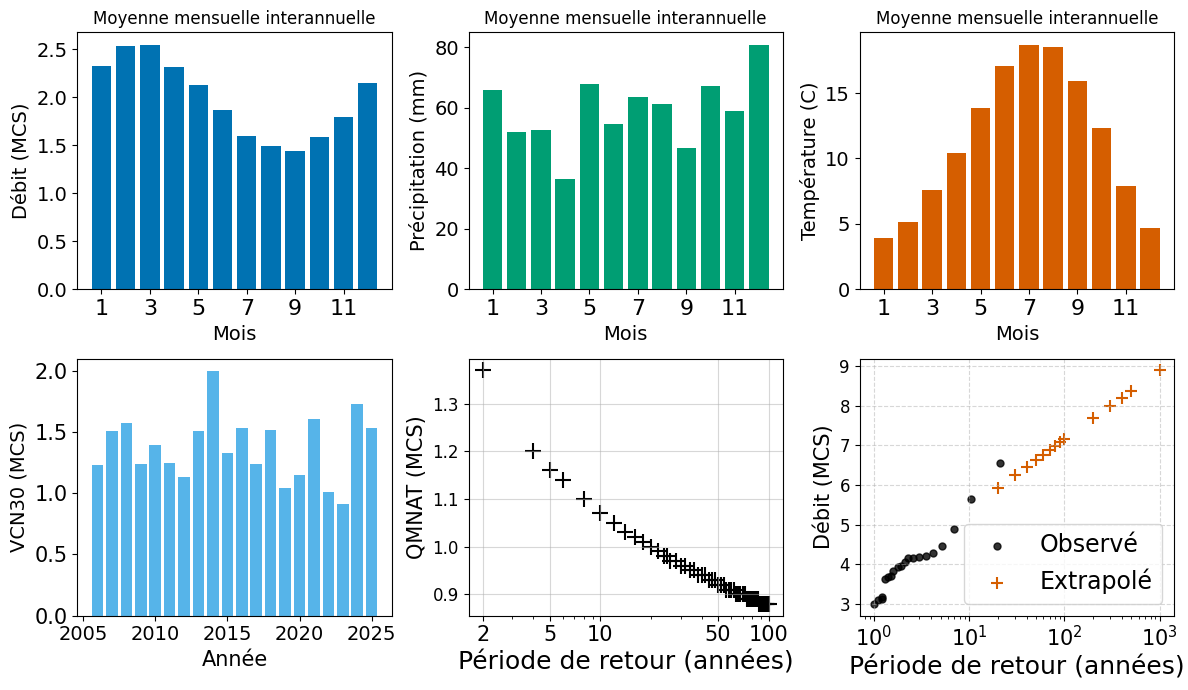

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))


axes[0, 0].bar(DATAFRAME_MOY_MENSUELLE_INTERANNUELLE["month"], DATAFRAME_MOY_MENSUELLE_INTERANNUELLE["Q_cumec"], color="#0072B2")
axes[0, 0].set_xlabel("Mois", fontsize=14)
axes[0, 0].set_ylabel("Débit (MCS)", fontsize=14)
axes[0, 0].set_xticks(np.arange(1, 13, 2))
axes[0, 0].set_title("Moyenne mensuelle interannuelle")
axes[0, 0].tick_params(axis="x", labelsize=16)
axes[0, 0].tick_params(axis="y", labelsize=14)

axes[0, 1].bar(DATAFRAME_MOY_MENSUELLE_INTERANNUELLE["month"], DATAFRAME_MOY_MENSUELLE_INTERANNUELLE["Pre_Moy"], color="#009E73")
axes[0, 1].set_xlabel("Mois", fontsize=14)
axes[0, 1].set_ylabel("Précipitation (mm)", fontsize=14)
axes[0, 1].set_xticks(np.arange(1, 13, 2))
axes[0, 1].set_title("Moyenne mensuelle interannuelle")
axes[0, 1].tick_params(axis="x", labelsize=16)
axes[0, 1].tick_params(axis="y", labelsize=14)

axes[0, 2].bar(DATAFRAME_MOY_MENSUELLE_INTERANNUELLE["month"], DATAFRAME_MOY_MENSUELLE_INTERANNUELLE["T_moy"], color="#D55E00")
axes[0, 2].set_xlabel("Mois", fontsize=14)
axes[0, 2].set_ylabel("Température (C)", fontsize=14)
axes[0, 2].set_xticks(np.arange(1, 13, 2))
axes[0, 2].set_title("Moyenne mensuelle interannuelle")
axes[0, 2].tick_params(axis='x', labelsize=16)
axes[0, 2].tick_params(axis='y', labelsize=14)


axes[1, 0].bar(VCN30["Annee"], VCN30["Q30"], color="#56B4E9")
axes[1, 0].set_xlabel("Année", fontsize=15)
axes[1, 0].set_ylabel("VCN30 (MCS)", fontsize=14)
axes[1, 0].tick_params(axis='x', labelsize=14)
axes[1, 0].tick_params(axis='y', labelsize=15)

axes[1, 1].scatter(QMNAT["T"], QMNAT["QMNA"], marker="+", s=120, color="#000000")
axes[1, 1].set_xlabel("Période de retour (années)", fontsize=18)
axes[1, 1].set_xscale("log")
axes[1, 1].grid(True, linestyle="-", alpha=0.5)
axes[1, 1].tick_params(axis='x', labelsize=15)
axes[1, 1].tick_params(axis='y', labelsize=12)
axes[1, 1].set_xticks([2, 5, 10, 50, 100])
axes[1, 1].set_xticklabels(["2", "5", "10", "50", "100"])
axes[1, 1].set_ylabel("QMNAT (MCS)", fontsize=15)

axes[1, 2].scatter(Max_deb_sorted["T"], Max_deb_sorted["Q_cumec"], s=25, label="Observé", alpha=0.8, color= "#000000")
axes[1, 2].scatter(df_extrap["T"], df_extrap["Q_extrap"], marker="+", s=80, label="Extrapolé", color="#D55E00")
axes[1, 2].set_xscale("log")
axes[1, 2].tick_params(axis='x', labelsize=15)
axes[1, 2].tick_params(axis='y', labelsize=12)
axes[1, 2].set_xlabel("Période de retour (années)", fontsize=18)
axes[1, 2].set_ylabel("Débit (MCS)", fontsize=15)
axes[1, 2].grid(True, linestyle="--", alpha=0.5)
axes[1, 2].legend(fontsize=17)


fig.tight_layout()

## Graphes (moyennes annuelles Q, P et T)

In [39]:
DATAFRAME_auunel_moy_P = DATAFRAME.groupby(["Annee"])["Pre_Moy"].sum().astype(int)
DATAFRAME_auunel_moy_T = DATAFRAME.groupby(["Annee"])["T_moy"].mean().round(1).dropna()
DATAFRAME_auunel_moy_Q = DATAFRAME.groupby(["Annee"])["Q_cumec"].mean().round(2)

temp_DATAFRAME_MOY_ANNUEL = pd.merge(DATAFRAME_auunel_moy_P, DATAFRAME_auunel_moy_T, on="Annee", how="outer")
DATAFRAME_MOY_ANNUEL = pd.merge(temp_DATAFRAME_MOY_ANNUEL, DATAFRAME_auunel_moy_Q, on = "Annee", how="outer")
DATAFRAME_MOY_ANNUEL = pd.DataFrame(DATAFRAME_MOY_ANNUEL).reset_index()

In [40]:
DATAFRAME_MOY_ANNUEL.head()

,Annee,Pre_Moy,T_moy,Q_cumec
0,2006,739,11.5,1.67
1,2007,793,11.2,1.97
2,2008,693,10.6,2.14
3,2009,686,10.7,1.92
4,2010,626,9.5,1.93


In [41]:
dataframe

,NOM_USUEL,Annee,P_annuel,mu_P,sigma_P,SPI
2,AIRION,1989,498.4,658.854545,131.321157,-1.221848
3,AIRION,1990,546.4,658.854545,131.321157,-0.856332
4,AIRION,1991,512.4,658.854545,131.321157,-1.115240
5,AIRION,1992,682.6,658.854545,131.321157,0.180820
6,AIRION,1993,734.6,658.854545,131.321157,0.576796
...,...,...,...,...,...,...
2671,WAVIGNIES,2008,506.5,534.583333,47.832433,-0.587119
2672,WAVIGNIES,2009,535.0,534.583333,47.832433,0.008711
2673,WAVIGNIES,2010,455.5,534.583333,47.832433,-1.653341
2674,WAVIGNIES,2011,550.5,534.583333,47.832433,0.332759


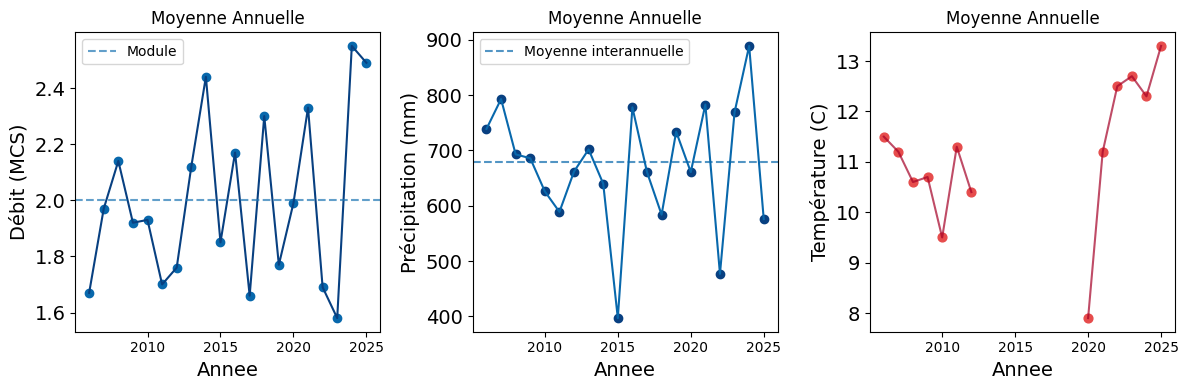

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))


axes[0].plot(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Q_cumec"], color="#084081")
axes[0].scatter(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Q_cumec"], color="#0868ac")
axes[0].axhline(2, linestyle = "--", alpha= 0.7, label="Module")
axes[0].set_xlabel("Annee", fontsize=14)
axes[0].set_ylabel("Débit (MCS)", fontsize=14)
axes[0].set_title("Moyenne Annuelle")
axes[0].tick_params(axis='y', labelsize=14)
axes[0].legend()


axes[1].plot(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Pre_Moy"], color="#0868ac")
axes[1].scatter(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Pre_Moy"], color="#084081")
axes[1].axhline(680, linestyle = "--", alpha= 0.7, label="Moyenne interannuelle", color="#0868ac") 
axes[1].set_xlabel("Annee", fontsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].set_ylabel("Précipitation (mm)", fontsize=14)
axes[1].set_title("Moyenne Annuelle")
axes[1].legend()




axes[2].set_ylabel("Température (C)", fontsize=14)
axes[2].set_title("Moyenne Annuelle") 
axes[2].plot(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["T_moy"], color="#a50026", linewidth=1.5, alpha=0.7)
axes[2].scatter(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["T_moy"], color="#E64C4C", s=40)
axes[2].set_xlabel("Annee", fontsize=14)
axes[2].tick_params(axis='y', labelsize=14)

fig.tight_layout()




In [43]:
import warnings
warnings.filterwarnings("ignore")

np.float64(2.0014999999999996)

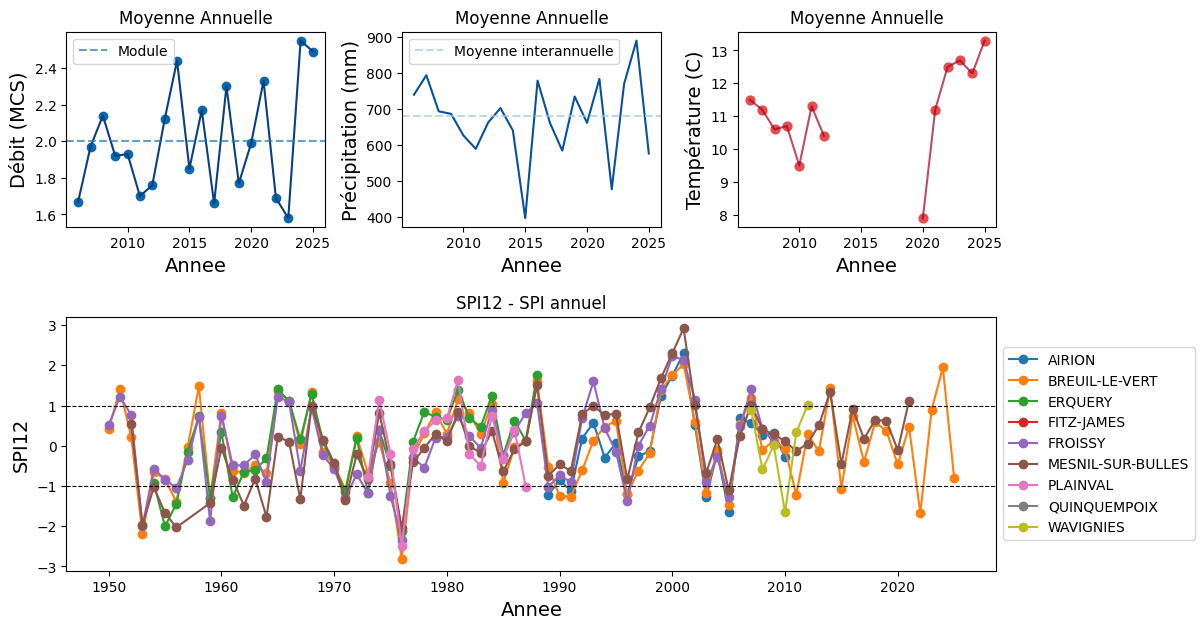

In [44]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 7))


gs = GridSpec(2, 3, figure=fig, height_ratios=[1, 1.3], hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Q_cumec"], color="#084081")
ax1.scatter(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Q_cumec"], color="#0868ac")
ax1.axhline(2, linestyle = "--", alpha= 0.7, label="Module")
ax1.set_xlabel("Annee", fontsize=14)
ax1.set_ylabel("Débit (MCS)", fontsize=14)
ax1.set_title("Moyenne Annuelle")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["Pre_Moy"], color="#08519c")
ax2.axhline(680, linestyle = "--", alpha= 0.7, label="Moyenne interannuelle", color="#9ecae1") 
ax2.set_xlabel("Annee", fontsize=14)
ax2.set_ylabel("Précipitation (mm)", fontsize=14)
ax2.set_title("Moyenne Annuelle")
ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])

ax3.set_xlabel("Annee", fontsize=14)
ax3.set_ylabel("Température (C)", fontsize=14)
ax3.set_title("Moyenne Annuelle") 
ax3.plot(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["T_moy"], color="#a50026", linewidth=1.5, alpha=0.7)
ax3.scatter(DATAFRAME_MOY_ANNUEL["Annee"], DATAFRAME_MOY_ANNUEL["T_moy"], color="#E64C4C", s=40)


ax_large = fig.add_subplot(gs[1, 0:3])


for i in dataframe["NOM_USUEL"].unique():
    data = dataframe[dataframe["NOM_USUEL"] == i]
    plt.plot(data["Annee"], data["SPI"], marker='o', label=i)

ax_large.set_xlabel("Annee", fontsize=14)
ax_large.set_ylabel("SPI12", fontsize=14)
ax_large.axhline(y=1, linestyle="--", linewidth=0.8, c="black")
ax_large.axhline(y=-1, linestyle="--", linewidth=0.8, c="black")
ax_large.set_title("SPI12 - SPI annuel")
ax_large.legend(loc="center left", bbox_to_anchor =(1, 0.5))

#ax_extra = fig.add_subplot(gs[1, 2])


plt.tight_layout()

modul = DATAFRAME_MOY_ANNUEL["Q_cumec"].mean()
modul

## Hydrogramme et limnigramme sur un même graphique

No. de jour débit: 6914 No. de jour pluie: 6914


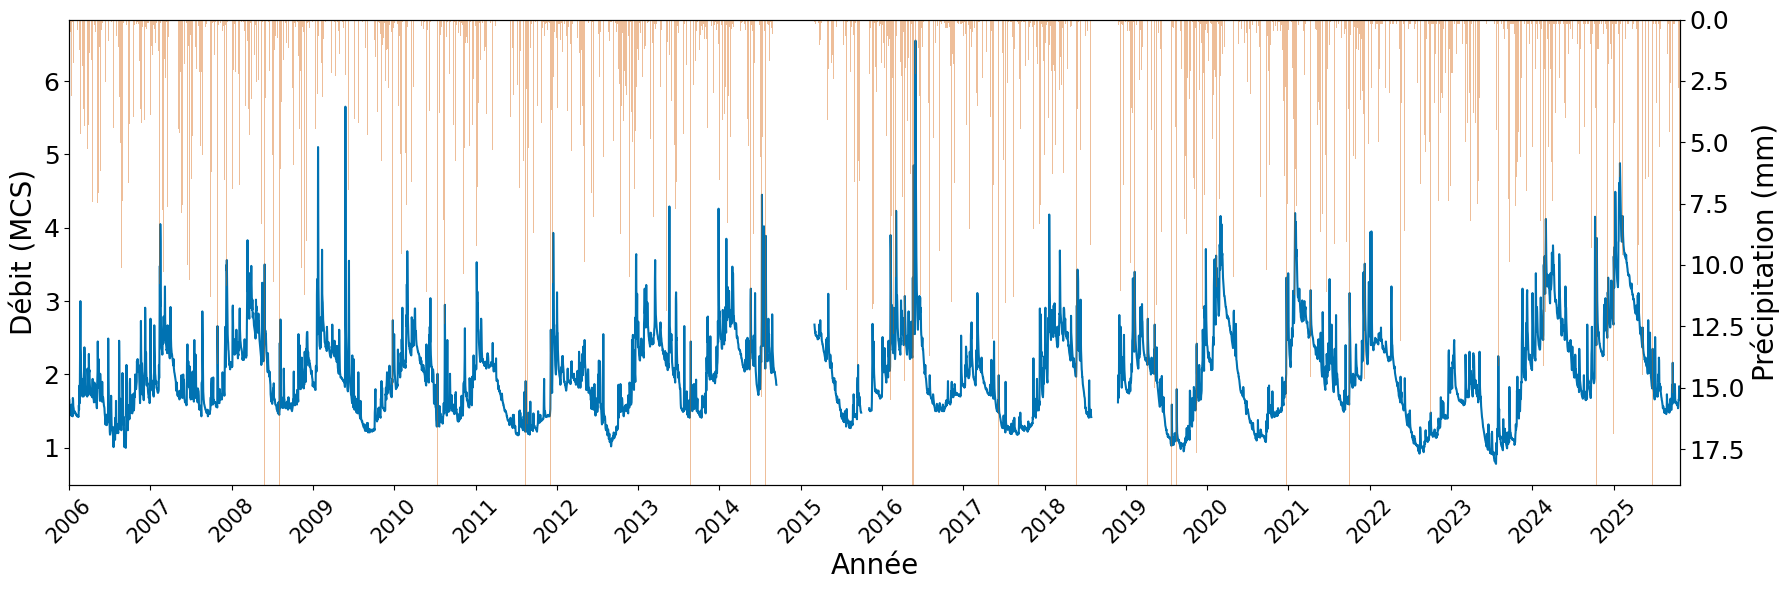

In [45]:
DF = DATAFRAME.copy()
DF["Date"] = pd.to_datetime(DF["Date"], errors="coerce")


DF = DF.sort_values("Date").dropna(subset=["Date"]).drop_duplicates("Date").set_index("Date")


if len(DF) == 0:
    raise ValueError("No DaTa")
full_idx = pd.date_range(DF.index.min(), DF.index.max(), freq="D")
DF = DF.reindex(full_idx)

print("No. de jour débit:", DF["Q_cumec"].notna().sum(), "No. de jour pluie:", DF["Pre_Moy"].notna().sum())


fig, ax1 = plt.subplots(figsize=(18,6))


if DF["Q_cumec"].notna().any():
    ax1.plot(DF.index, DF["Q_cumec"], color="#0072B2", label="Débit (MCS)", zorder=2)

ax1.set_xlabel("Année", fontsize=20)
ax1.set_ylabel("Débit (MCS)", fontsize=20)
ax1.tick_params(axis="y", labelsize=18)
ax1.tick_params(axis="x", labelsize=15, rotation=45)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_xlim(DF.index.min(), DF.index.max())


ax2 = ax1.twinx()
mask = DF["Pre_Moy"].notna()
if mask.any():
    ax2.bar(DF.index[mask], DF.loc[mask, "Pre_Moy"], color="#D55E00", alpha=0.4, width=1.0, zorder=1)
    ymax = np.nanpercentile(DF["Pre_Moy"], 99)
    ax2.set_ylim(ymax, 0)
    ax2.set_ylabel("Précipitation (mm)", fontsize=20)
    ax2.tick_params(axis="y", labelsize=18)

plt.tight_layout()
plt.show()
